In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

In [2]:
# Data 
# URLs for datasets
HURDAT2_URL = "https://www.nhc.noaa.gov/data/hurdat/hurdat2-1851-2023-051124.txt"
GISTEMP_URL = "https://data.giss.nasa.gov/gistemp/graphs/graph_data/Global_Mean_Estimates_based_on_Land_and_Ocean_Data/graph.txt"


# Load the HURDAT2 hurricane dataset
def load_hurdat2_data(url=HURDAT2_URL):
    # Fetch and read the dataset
    response = requests.get(url)
    data = response.text.splitlines()
    
    # Parse the data
    rows = []
    current_storm_id = None
    current_storm_name = None
    
    for line in data:
        parts = [p.strip() for p in line.split(',')]
        
        # Header lines start with AL (Atlantic) followed by numbers
        if parts[0].startswith('AL'):
            current_storm_id = parts[0]
            current_storm_name = parts[1].strip()  # The name is in the second part
            # Skip the rest of this iteration as it's just a header
            continue
            
        # If it's not a header line, it's a data line
        if len(parts) > 7:  # Data lines have many columns
            try:
                max_winds = float(parts[6]) if parts[6].strip() != '-999' else None
                min_pressure = float(parts[7]) if parts[7].strip() != '-999' else None
            except ValueError:
                max_winds = None
                min_pressure = None
                
            rows.append({
                "storm_id": current_storm_id,
                "storm_name": current_storm_name,
                "date": parts[0].strip(),
                "time": parts[1].strip(),
                "record_identifier": parts[2].strip(),
                "status": parts[3].strip(),
                "latitude": parts[4].strip(),
                "longitude": parts[5].strip(),
                "max_winds": max_winds,
                "min_pressure": min_pressure
            })
    
    # Load into a DataFrame
    df = pd.DataFrame(rows)
    
    # Convert datetime and create year column
    df['datetime'] = pd.to_datetime(df['date'] + df['time'], format='%Y%m%d%H%M', errors='coerce')
    df = df.dropna(subset=['datetime'])
    df['year'] = df['datetime'].dt.year
    
    # Define category based on max_winds (Saffir-Simpson scale)
    df['category'] = df['max_winds'].apply(lambda x: (
        0 if pd.isna(x) or x < 34 else  # Tropical Depression
        1 if x <= 63 else  # Tropical Storm
        2 if x <= 82 else  # Category 1
        3 if x <= 95 else  # Category 2
        4 if x <= 112 else  # Category 3
        5 if x <= 136 else  # Category 4
        6  # Category 5
    ))
    
    return df

def unique_hurricanes() -> pd.DataFrame:
    hurdat2_df = load_hurdat2_data()
    hurricanes = hurdat2_df[
        (hurdat2_df['storm_name'].notna()) &
        (hurdat2_df['storm_name'].str.strip() != '')
    ].copy()

    # Group by storm to get unique hurricanes
    unique_hurricanes = hurricanes.groupby(['storm_name', 'year']).agg({
        'category': 'max',
        'max_winds': 'max',
        'min_pressure': 'min',
        'date': 'first'
    }).reset_index()

    # Sort by year and name
    unique_hurricanes = unique_hurricanes.sort_values(['year', 'storm_name'])

    # Show results
    # print("Sample of Cat 4-5 hurricanes:")
    # print(unique_major_hurricanes.head(10))
    #print("\nTotal number of Cat 4-5 hurricanes:", len(unique_major_hurricanes))

    # Also show some summary stats
    # print("\nDistribution by category:")
    return unique_hurricanes


def load_gistemp_data(url=GISTEMP_URL):
    # Fetch and read the dataset with headers to bypass the server's restrictions
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.36'}
    response = requests.get(url, headers=headers)
    data = response.text.splitlines()
    
    # Parse the data
    rows = []
    start_reading = False
    
    for line in data:
        parts = [p.strip() for p in line.split()]
        
        # Skip header lines
        if parts and parts[0] == "Year":
            start_reading = True
            continue
        
        if not start_reading:
            continue
        
        # Skip lines that don't have the correct data format
        if len(parts) != 3:
            continue
        
        # Parse the parts
        try:
            year = int(parts[0])
            temperature = float(parts[1])
            uncertainty = float(parts[2])
            rows.append({
                "year": year,
                "temperature_change": temperature,
                "lowess_temperature": uncertainty
            })
        except ValueError:
            continue
    
    # Load into a DataFrame
    df = pd.DataFrame(rows)
    
    return df

# Run the function to get the data
unique_hurricanes = unique_hurricanes()

# Run the function
gistemp_data = load_gistemp_data()

# Merge the datasets
merged_data = pd.merge(unique_hurricanes, gistemp_data, on='year', how='inner')

# Keep only the last 30 years
merged_data = merged_data[merged_data['year'] >= 1990]

# Show the merged data
merged_data.head()

,storm_name,year,category,max_winds,min_pressure,date,temperature_change,lowess_temperature
452,ARTHUR,1990,1,60.0,995.0,19900722,0.45,0.33
453,BERTHA,1990,2,70.0,973.0,19900724,0.45,0.33
454,CESAR,1990,1,45.0,1000.0,19900731,0.45,0.33
455,DIANA,1990,3,85.0,980.0,19900804,0.45,0.33
456,EDOUARD,1990,1,40.0,1003.0,19900802,0.45,0.33


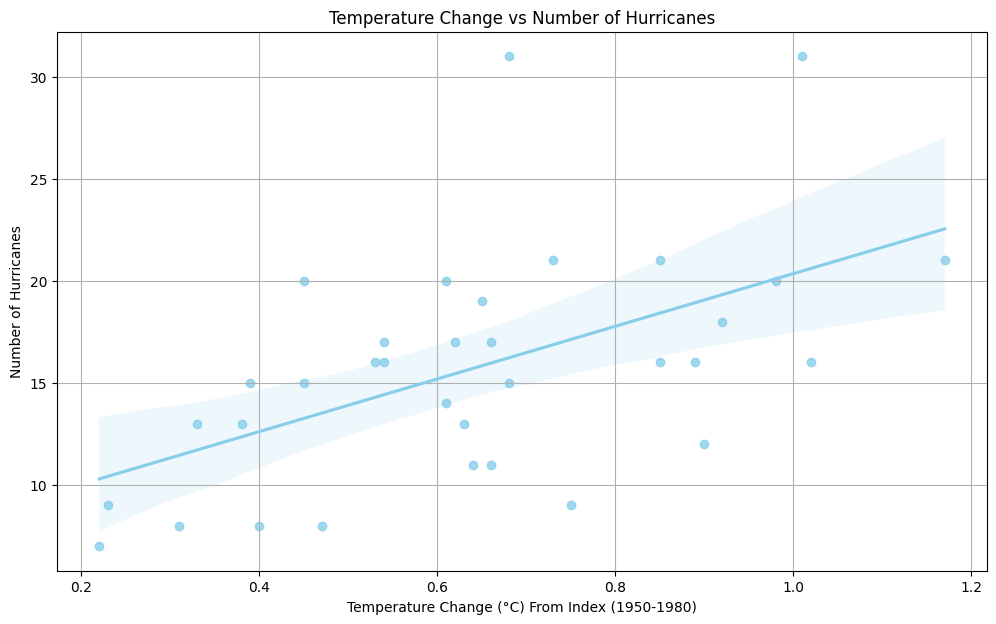

In [3]:
# Plot 1: Relationship bewtween higher temperature and more hurricanes
# Create a copy of the merged data
data = merged_data.copy()

# Aggregate by year, counting the number of hurricanes
hurricane_counts = data.groupby('year')['storm_name'].nunique()
# Get unique temperatures for each year
unique_temperatures = data.groupby('year')['temperature_change'].mean()

# Plotting a scatter plot with a line of best fit
plt.figure(figsize=(12, 7))
sns.regplot(x=unique_temperatures, y=hurricane_counts, color='skyblue')
plt.title('Temperature Change vs Number of Hurricanes')
plt.xlabel('Temperature Change (°C) From Index (1950-1980)')
plt.ylabel('Number of Hurricanes')
plt.grid(True)
plt.show()

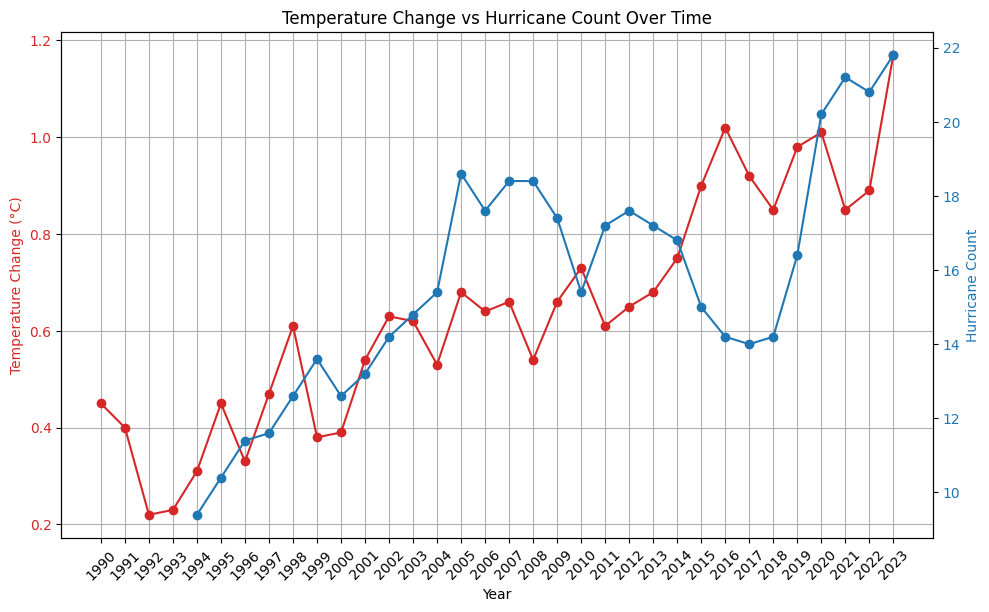

In [4]:
# Plot 2: Increasing temperature and increasing number of hurricanes
# Aggregate by year to count hurricanes
hurricane_counts = data.groupby("year")["storm_name"].nunique()

# Calculate the 5-year rolling average
hurricane_counts_rolling = hurricane_counts.rolling(window=5).mean()

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot temperature change on the first y-axis
ax1.set_xlabel('Year')
ax1.set_ylabel('Temperature Change (°C)', color='tab:red')
ax1.plot(data['year'].unique(), data.groupby('year')['temperature_change'].mean(), color='tab:red', label="Temperature Change", marker='o')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.set_xticks(data['year'].unique())
ax1.set_xticklabels(data['year'].unique(), rotation=45)
ax1.grid(True)  # Add gridlines to the first y-axis

# Create a second y-axis for hurricane counts
ax2 = ax1.twinx()  
ax2.set_ylabel('Hurricane Count', color='tab:blue')
ax2.plot(hurricane_counts_rolling.index, hurricane_counts_rolling.values, color='tab:blue', label="Hurricane Count", marker='o')
ax2.tick_params(axis='y', labelcolor='tab:blue')

fig.tight_layout()  # Adjust the layout for better spacing
plt.title('Temperature Change vs Hurricane Count Over Time')
plt.show()


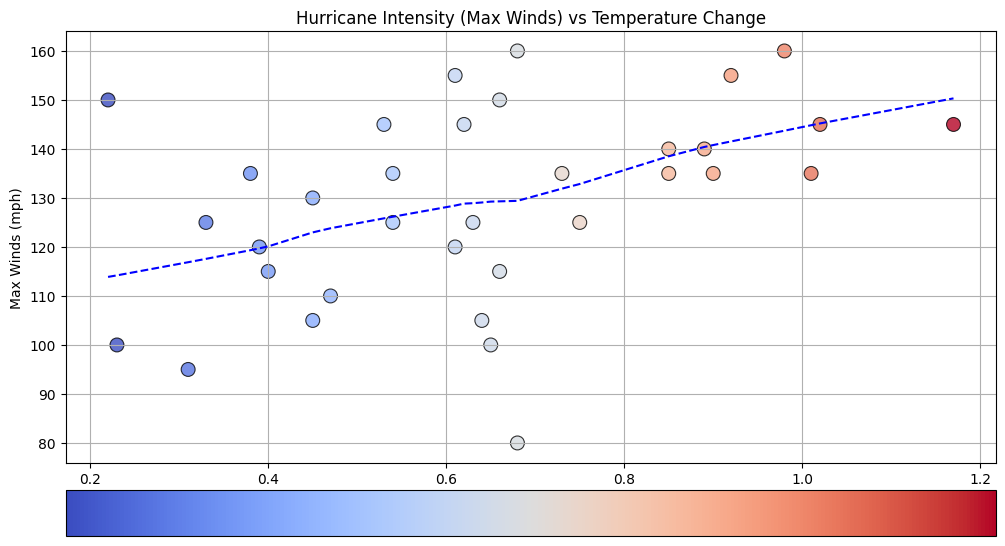

In [9]:
# Plot 3: Relationship between higher temperature and stronger hurricanes
# Aggregate data to get the highest wind speed per year
max_winds_per_year = data.groupby('year')['max_winds'].max().reset_index()

# Merge the aggregated data with the original data to retain temperature_change information
max_winds_data = max_winds_per_year.merge(data[['year', 'max_winds', 'temperature_change']], on=['year', 'max_winds'], how='left').drop_duplicates()

plt.figure(figsize=(12, 7))

# Scatter plot with color gradient for temperature change and point size based on frequency or impact (if available)
scatter = sns.scatterplot(
    data=max_winds_data,
    x='temperature_change',
    y='max_winds',
    hue='temperature_change',  # Use temperature as a color gradient
    palette='coolwarm',
    edgecolor='black',  # Outline for contrast
    s=100,  # Uniform size to avoid overlap issues
    alpha=0.8
)

# Add a trend line (lowess for nonlinear relationship)
sns.regplot(
    data=max_winds_data,
    x='temperature_change',
    y='max_winds',
    scatter=False,
    color='blue',
    lowess=True,
    line_kws={'linestyle': '--', 'linewidth': 1.5}
)
# Remove legend
scatter.get_legend().remove()

plt.title('Hurricane Intensity (Max Winds) vs Temperature Change')
plt.xlabel('Temperature Change (°C)')
plt.ylabel('Max Winds (mph)')

# Use the mappable from the scatter plot for the color bar
norm = plt.Normalize(data['temperature_change'].min(), data['temperature_change'].max())
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=scatter.axes, orientation='horizontal', pad=0.05, label='')
cbar.ax.tick_params(labelsize=10, labelbottom=False, bottom=False)  # Remove tick labels from color bar

plt.grid(True)
plt.show()


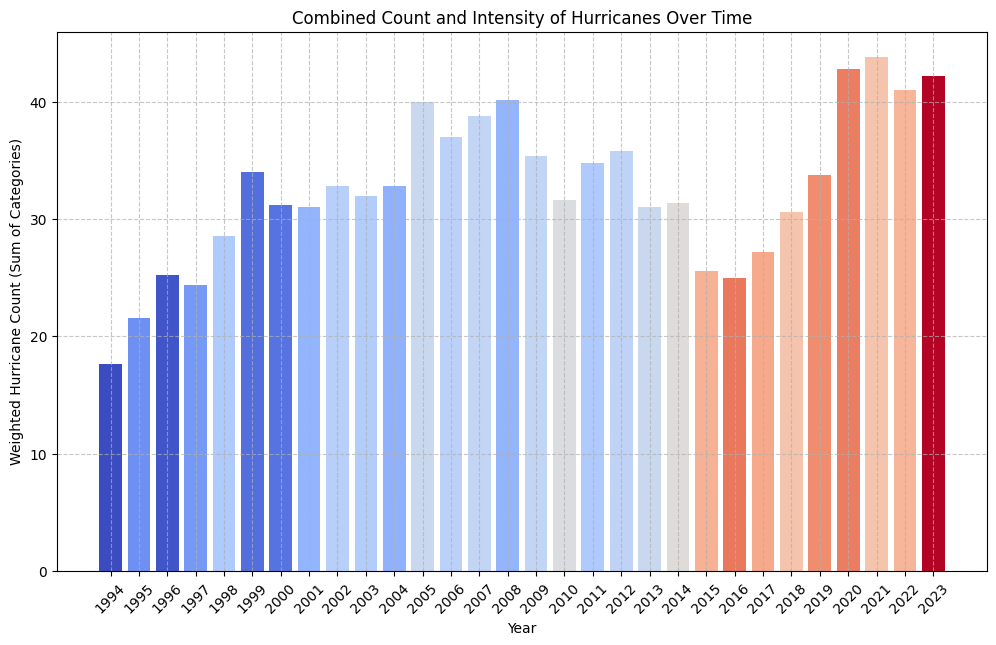

In [12]:
# Plot 4: Smoothed weighted score of hurricanes over time with temperature-based bar colors
# Aggregate by year, summing the storm weights (category values)
weighted_hurricane_counts = data.groupby('year')['category'].sum().reset_index()

# Calculate the 5-year rolling average
weighted_hurricane_counts['rolling_average'] = weighted_hurricane_counts['category'].rolling(window=5).mean()

# Filter out the first 4 years to start displaying from year 5
filtered_weighted_hurricane_counts = weighted_hurricane_counts.dropna()

# Aggregate data to get the mean temperature change per year
temperature_change_per_year = data.groupby('year')['temperature_change'].mean().reset_index()

# Remove the first 4 years to match the hurricane data
temperature_change_per_year = temperature_change_per_year[temperature_change_per_year['year'] >= 1994]

# Merge the temperature data with the hurricane data
merged_data = filtered_weighted_hurricane_counts.merge(temperature_change_per_year, on='year')

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 7))

# Create a color map based on temperature change
norm = plt.Normalize(merged_data['temperature_change'].min(), merged_data['temperature_change'].max())
colors = plt.cm.coolwarm(norm(merged_data['temperature_change']))

# Plot weighted hurricane counts as a bar plot with color mapping
bars = ax1.bar(merged_data['year'], merged_data['rolling_average'], color=colors)
ax1.set_xlabel('Year')
ax1.set_ylabel('Weighted Hurricane Count (Sum of Categories)')
ax1.set_xticks(merged_data['year'])
ax1.set_xticklabels(merged_data['year'], rotation=45)
ax1.grid(True, linestyle='--', alpha=0.7)

plt.title('Combined Count and Intensity of Hurricanes Over Time')
plt.show()
